# Phase 5 — Simple English Wikipedia Jargon Frequency List

This notebook builds the jargon detection system used in the audience suitability score formula.

**Approach:** Words rare in Simple English Wikipedia are treated as jargon. Simple English Wikipedia is written for non-native speakers and younger audiences — making it a principled, domain-agnostic benchmark for accessibility.

**Output:** `data/jargon/word_frequencies.json` — word frequency tiers used at inference time.

---

In [1]:
import json
import re
import urllib.request
import urllib.parse
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt

Path("data/jargon").mkdir(parents=True, exist_ok=True)

print("Setup complete!")
print("Target: Simple English Wikipedia word frequency list")
print("Output: data/jargon/word_frequencies.json")

Setup complete!
Target: Simple English Wikipedia word frequency list
Output: data/jargon/word_frequencies.json



### Fetching Simple English Wikipedia


In [2]:
def fetch_simple_wiki_article(title):
    """Fetch plain text of a Simple English Wikipedia article."""
    url = "https://simple.wikipedia.org/w/api.php"
    params = {
        "action": "query",
        "titles": title,
        "prop": "extracts",
        "explaintext": True,
        "format": "json"
    }
    
    headers = {
        "User-Agent": "Mozilla/5.0 (educational research; anisharay08@gmail.com)"
    }
    
    query = urllib.parse.urlencode(params)
    full_url = f"{url}?{query}"
    
    try:
        req = urllib.request.Request(full_url, headers=headers)
        with urllib.request.urlopen(req, timeout=10) as response:
            data = json.loads(response.read().decode())
        
        pages = data.get("query", {}).get("pages", {})
        for page_id, page in pages.items():
            if page_id != "-1":
                return page.get("extract", "")
        return ""
    
    except Exception as e:
        print(f"Error fetching {title}: {e}")
        return ""

# Diverse topics to sample from Simple English Wikipedia
topics = [
    # Science
    "Science", "Biology", "Chemistry", "Physics", "Mathematics",
    "Astronomy", "Geology", "Ecology", "Evolution", "Genetics",
    # Technology
    "Computer", "Internet", "Electricity", "Robot", "Machine",
    "Telephone", "Television", "Radio", "Satellite", "Software",
    # History and society
    "History", "Democracy", "Economy", "Culture", "Religion",
    "War", "Government", "Law", "Education", "Language",
    # Nature
    "Animal", "Plant", "Water", "Weather", "Climate",
    "Ocean", "Mountain", "Forest", "Desert", "River",
    # Health
    "Medicine", "Health", "Disease", "Brain", "Heart",
    "Nutrition", "Exercise", "Virus", "Bacteria", "Cancer",
    # Arts and everyday
    "Music", "Art", "Sport", "Food", "Family",
    "Money", "Travel", "House", "Clothing", "Work",
]

print(f"Fetching {len(topics)} Simple English Wikipedia articles...")
print("This will take a few minutes...\n")

all_text = ""
fetched = 0

for i, topic in enumerate(topics):
    text = fetch_simple_wiki_article(topic)
    if text:
        all_text += " " + text
        fetched += 1
    
    if (i + 1) % 10 == 0:
        print(f"[{i+1}/{len(topics)}] Fetched {fetched} articles, "
              f"{len(all_text.split()):,} words so far")
    
    import time
    time.sleep(0.3)

print(f"\nTotal text collected: {len(all_text.split()):,} words from {fetched} articles")

Fetching 60 Simple English Wikipedia articles...
This will take a few minutes...

[10/60] Fetched 10 articles, 63,671 words so far
[20/60] Fetched 20 articles, 73,046 words so far
[30/60] Fetched 30 articles, 83,056 words so far
[40/60] Fetched 40 articles, 114,942 words so far
[50/60] Fetched 49 articles, 126,135 words so far
[60/60] Fetched 59 articles, 137,218 words so far

Total text collected: 137,218 words from 59 articles



### Building word frequency counts


In [3]:
def clean_and_tokenise(text):
    """Clean text and extract words."""
    # Lowercase
    text = text.lower()
    # Remove punctuation, keep letters and spaces
    text = re.sub(r'[^a-z\s]', ' ', text)
    # Split into words
    words = text.split()
    # Filter very short words (1-2 chars)
    words = [w for w in words if len(w) > 2]
    return words

print("Counting word frequencies...")
words = clean_and_tokenise(all_text)
word_counts = Counter(words)

print(f"\nTotal words (cleaned): {len(words):,}")
print(f"Unique words: {len(word_counts):,}")

print(f"\nTop 20 most common words:")
for word, count in word_counts.most_common(20):
    print(f"  {word}: {count:,}")

print(f"\nSample rare words (appearing 1-5 times):")
rare = [(w, c) for w, c in word_counts.items() if 1 <= c <= 5][:15]
for word, count in rare:
    print(f"  {word}: {count}")

Counting word frequencies...

Total words (cleaned): 112,433
Unique words: 10,390

Top 20 most common words:
  the: 6,929
  and: 4,489
  are: 1,523
  that: 1,483
  water: 1,273
  this: 1,013
  for: 992
  they: 970
  can: 846
  like: 809
  people: 745
  from: 709
  called: 668
  not: 640
  have: 626
  was: 605
  which: 596
  also: 582
  with: 565
  how: 558

Sample rare words (appearing 1-5 times):
  psychology: 5
  sociology: 5
  categorized: 1
  beginnings: 2
  hindu: 3
  fell: 2
  slowed: 2
  byzantine: 2
  weaker: 2
  removed: 3
  calling: 2
  etymology: 1
  terminology: 3
  philosophies: 1
  scientia: 2



### Supplement word lists


In [4]:
# Dolch word list — 220 most common sight words (grades K-3)
dolch_words = {
    "the", "and", "a", "to", "said", "in", "he", "i", "of", "it",
    "was", "you", "they", "she", "we", "but", "not", "what", "all",
    "were", "when", "your", "can", "there", "use", "an", "each",
    "which", "do", "how", "their", "if", "will", "up", "other",
    "about", "out", "many", "then", "them", "these", "so", "some",
    "her", "would", "make", "like", "him", "into", "time", "has",
    "look", "two", "more", "write", "go", "see", "number", "no",
    "way", "could", "people", "my", "than", "first", "water", "been",
    "called", "who", "oil", "sit", "now", "find", "long", "down",
    "day", "did", "get", "come", "made", "may", "part", "over",
    "new", "sound", "take", "only", "little", "work", "know", "place",
    "year", "live", "me", "back", "give", "most", "very", "after",
    "thing", "our", "just", "name", "good", "sentence", "man", "think",
    "say", "great", "where", "help", "through", "much", "before", "line",
    "right", "too", "mean", "old", "any", "same", "tell", "boy",
    "follow", "came", "want", "show", "also", "around", "farm", "three",
    "small", "set", "put", "end", "does", "another", "well", "large",
    "must", "big", "even", "such", "because", "turned", "here", "why",
    "asked", "went", "men", "read", "need", "land", "different", "home",
    "move", "try", "kind", "hand", "picture", "again", "change", "off",
    "play", "spell", "air", "away", "animal", "house", "point", "page",
    "letter", "mother", "answer", "found", "study", "still", "learn",
    "plant", "cover", "food", "sun", "four", "between", "state", "keep",
    "eye", "never", "last", "let", "thought", "city", "tree", "cross",
    "since", "hard", "start", "might", "story", "saw", "far", "sea",
    "draw", "left", "late", "run", "while", "press", "close", "night",
    "real", "open", "seem", "together", "next", "white", "children",
    "begin", "got", "walk", "example", "ease", "paper", "group", "always",
    "music", "those", "both", "mark", "book", "carry", "took", "science",
    "eat", "room", "friend", "began", "idea", "fish", "mountain", "stop",
    "once", "base", "hear", "horse", "cut", "sure", "watch", "color",
    "face", "wood", "main", "enough", "plain", "girl", "usual", "young",
    "ready", "above", "ever", "red", "list", "though", "feel", "talk",
    "bird", "soon", "body", "dog", "family", "direct", "pose", "leave",
    "song", "measure", "door", "product", "black", "short", "numeral",
    "class", "wind", "question", "happen", "complete", "ship", "area",
    "half", "rock", "order", "fire", "south", "problem", "piece", "told",
    "knew", "pass", "since", "top", "whole", "king", "space", "heard",
    "best", "hour", "better", "true", "during", "hundred", "five", "remember",
    "step", "early", "hold", "west", "ground", "interest", "reach", "fast",
    "verb", "sing", "listen", "six", "table", "travel", "less", "morning",
}

# Fry word list — 1000 most common words in English
# (using first 500 as supplement)
fry_words = {
    "about", "above", "across", "act", "active", "actual", "add", "admit",
    "afraid", "after", "again", "age", "ago", "agree", "ahead", "allow",
    "almost", "alone", "along", "already", "also", "although", "always",
    "among", "amount", "angry", "another", "appear", "arm", "art", "ask",
    "at", "attack", "attempt", "attention", "authority", "available", "avoid",
    "ball", "basic", "beautiful", "become", "bed", "believe", "below",
    "beside", "best", "better", "between", "beyond", "bit", "black", "blood",
    "blue", "board", "born", "box", "break", "bring", "build", "business",
    "buy", "call", "car", "care", "carry", "case", "catch", "cause",
    "cent", "central", "certain", "chance", "character", "charge", "check",
    "clear", "cold", "common", "community", "complete", "condition", "consider",
    "contain", "continue", "control", "cost", "country", "create", "current",
    "dark", "dead", "deal", "decide", "deep", "describe", "develop",
    "difference", "difficult", "direction", "discover", "distance", "divide",
    "drive", "drop", "due", "each", "east", "effect", "effort", "either",
    "else", "enter", "equal", "especially", "establish", "event", "everyone",
    "everything", "except", "exist", "expect", "experience", "explain",
    "fall", "false", "familiar", "father", "feel", "few", "field", "fight",
    "figure", "final", "force", "form", "free", "front", "full", "future",
    "general", "glass", "gold", "gone", "green", "grow", "guess", "happen",
    "happy", "hard", "have", "head", "heavy", "high", "hope", "hot",
    "idea", "include", "increase", "industry", "information", "inside",
    "instead", "involve", "island", "job", "join", "just", "keep", "kill",
    "known", "level", "light", "likely", "live", "local", "long", "lose",
    "low", "major", "matter", "meet", "member", "method", "middle", "might",
    "military", "million", "mind", "miss", "model", "moment", "nation",
    "nature", "near", "necessary", "note", "nothing", "notice", "number",
    "office", "often", "once", "only", "open", "organization", "original",
    "others", "outside", "own", "past", "pay", "peace", "perhaps", "period",
    "person", "physical", "pick", "plan", "political", "popular", "position",
    "possible", "power", "present", "price", "probably", "process",
    "production", "program", "provide", "public", "purpose", "quality",
    "question", "quickly", "quite", "raise", "rate", "rather", "reach",
    "reason", "receive", "recently", "record", "remain", "report", "require",
    "rest", "result", "return", "rise", "road", "role", "rule", "safe",
    "season", "second", "section", "seem", "serious", "serve", "several",
    "share", "show", "side", "significant", "similar", "simple", "single",
    "situation", "size", "skill", "slow", "social", "society", "south",
    "specific", "spend", "stand", "strong", "structure", "subject",
    "success", "support", "system", "taken", "talk", "task", "term",
    "test", "theory", "therefore", "thousand", "today", "together", "total",
    "toward", "trade", "traditional", "treat", "tried", "turn", "type",
    "under", "understand", "unit", "until", "usually", "value", "various",
    "village", "voice", "whether", "wide", "without", "women", "world",
    "write", "wrong", "yet",
}

# Add supplement words to frequency counts
# Give them a high baseline count so they're always "common"
supplement_baseline = 5000

for word in dolch_words:
    if word in word_counts:
        word_counts[word] = max(word_counts[word], supplement_baseline)
    else:
        word_counts[word] = supplement_baseline

for word in fry_words:
    if word in word_counts:
        word_counts[word] = max(word_counts[word], supplement_baseline)
    else:
        word_counts[word] = supplement_baseline

print(f"Added {len(dolch_words)} Dolch words")
print(f"Added {len(fry_words)} Fry words")
print(f"Total unique words after supplement: {len(word_counts):,}")

Added 326 Dolch words
Added 321 Fry words
Total unique words after supplement: 10,418



### Building tiered jargon thresholds


In [10]:
def classify_word(word, freq):
    """
    Adjusted thresholds for smaller corpus size.
    
    Tiers:
      common    (freq >= 50):  everyday words — score 0.0
      familiar  (freq 10-49):  known words — score 0.3
      technical (freq 2-9):    specialised — score 0.7
      jargon    (freq < 2):    rare/domain — score 1.0
    """
    if freq >= 50:
        return "common", 0.0
    elif freq >= 10:
        return "familiar", 0.3
    elif freq >= 2:
        return "technical", 0.7
    else:
        return "jargon", 1.0

# Classify all words
word_tiers = {}
for word, freq in word_counts.items():
    tier, score = classify_word(word, freq)
    word_tiers[word] = {
        "frequency": freq,
        "tier": tier,
        "jargon_score": score
    }

# Count per tier
tier_counts = {"common": 0, "familiar": 0, "technical": 0, "jargon": 0}
for data in word_tiers.values():
    tier_counts[data["tier"]] += 1

print("Word tier distribution:")
total = sum(tier_counts.values())
for tier, count in tier_counts.items():
    print(f"  {tier:12s}: {count:6,} words ({count/total*100:.1f}%)")

# Test some words
print("\nTest classifications:")
test_words = [
    "the", "learning", "algorithm", "backpropagation",
    "gradient", "transformer", "mitosis", "photosynthesis",
    "dog", "computer", "eigenvalue", "quantization"
]

for word in test_words:
    if word in word_tiers:
        data = word_tiers[word]
        print(f"  {word:20s}: {data['tier']:12s} "
              f"(freq={data['frequency']:5,}, score={data['jargon_score']})")
    else:
        print(f"  {word:20s}: jargon       (freq=0, score=1.0) [not in vocabulary]")

Word tier distribution:
  common      :    789 words (7.6%)
  familiar    :    993 words (9.5%)
  technical   :  4,042 words (38.8%)
  jargon      :  4,594 words (44.1%)

Test classifications:
  the                 : common       (freq=6,929, score=0.0)
  learning            : familiar     (freq=   45, score=0.3)
  algorithm           : technical    (freq=    2, score=0.7)
  backpropagation     : jargon       (freq=0, score=1.0) [not in vocabulary]
  gradient            : technical    (freq=    3, score=0.7)
  transformer         : jargon       (freq=0, score=1.0) [not in vocabulary]
  mitosis             : technical    (freq=    8, score=0.7)
  photosynthesis      : familiar     (freq=   16, score=0.3)
  dog                 : common       (freq=5,000, score=0.0)
  computer            : common       (freq=  119, score=0.0)
  eigenvalue          : jargon       (freq=0, score=1.0) [not in vocabulary]
  quantization        : jargon       (freq=0, score=1.0) [not in vocabulary]



### Visualising the distribution


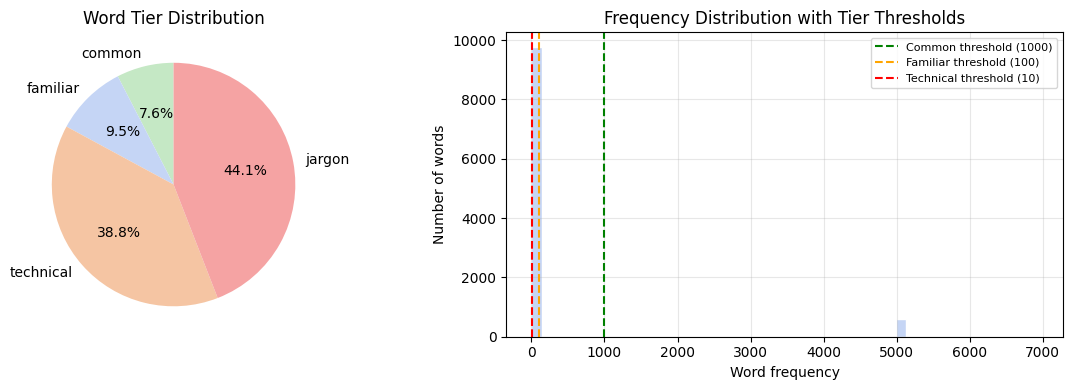

Distribution plot saved to data/jargon/frequency_distribution.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Tier distribution pie chart
ax = axes[0]
tier_labels = list(tier_counts.keys())
tier_values = list(tier_counts.values())
colors = ['#c5e8c5', '#c5d5f5', '#f5c5a3', '#f5a3a3']
ax.pie(tier_values, labels=tier_labels, colors=colors,
       autopct='%1.1f%%', startangle=90)
ax.set_title("Word Tier Distribution")

# Frequency histogram (log scale)
ax = axes[1]
freqs = [data["frequency"] for data in word_tiers.values()
         if data["frequency"] < 10000]
ax.hist(freqs, bins=50, color='#c5d5f5', edgecolor='white')
ax.axvline(x=1000, color='green', linestyle='--', label='Common threshold (1000)')
ax.axvline(x=100, color='orange', linestyle='--', label='Familiar threshold (100)')
ax.axvline(x=10, color='red', linestyle='--', label='Technical threshold (10)')
ax.set_xlabel("Word frequency")
ax.set_ylabel("Number of words")
ax.set_title("Frequency Distribution with Tier Thresholds")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("data/jargon/frequency_distribution.png", dpi=150)
plt.show()

print("Distribution plot saved to data/jargon/frequency_distribution.png")


### Saving the jargon frequency list


In [12]:
# Save full word tiers
output_path = "data/jargon/word_frequencies.json"
with open(output_path, "w") as f:
    json.dump(word_tiers, f, ensure_ascii=False)

print(f"Saved {len(word_tiers):,} words to {output_path}")

# Also save a lightweight version (just tier labels, no raw frequencies)
lightweight = {word: data["jargon_score"] 
               for word, data in word_tiers.items()}

lightweight_path = "data/jargon/jargon_scores.json"
with open(lightweight_path, "w") as f:
    json.dump(lightweight, f, ensure_ascii=False)

print(f"Saved lightweight version to {lightweight_path}")

# File sizes
import os
full_size = os.path.getsize(output_path) / (1024*1024)
light_size = os.path.getsize(lightweight_path) / (1024*1024)
print(f"\nFile sizes:")
print(f"  Full:        {full_size:.2f} MB")
print(f"  Lightweight: {light_size:.2f} MB")
print(f"\nLightweight version is what gets loaded at inference time.")

Saved 10,418 words to data/jargon/word_frequencies.json
Saved lightweight version to data/jargon/jargon_scores.json

File sizes:
  Full:        0.70 MB
  Lightweight: 0.16 MB

Lightweight version is what gets loaded at inference time.



### Jargon detection function


In [13]:
def compute_jargon_density(text, jargon_scores):
    """
    Compute jargon density of a text.
    
    Returns:
        float: Average jargon score across all words (0.0 to 1.0)
               0.0 = no jargon (all common words)
               1.0 = all jargon
    """
    # Clean and tokenise
    text_clean = re.sub(r'[^a-z\s]', ' ', text.lower())
    words = [w for w in text_clean.split() if len(w) > 2]
    
    if not words:
        return 0.0
    
    # Score each word
    scores = []
    for word in words:
        if word in jargon_scores:
            scores.append(jargon_scores[word])
        else:
            # Unknown word = jargon
            scores.append(1.0)
    
    return sum(scores) / len(scores)

# Load lightweight scores
with open("data/jargon/jargon_scores.json", "r") as f:
    jargon_scores = json.load(f)

# Test on examples
print("="*60)
print("JARGON DENSITY TEST")
print("="*60)

test_texts = [
    ("Simple text",
     "The dog sat in the park and looked at the birds."),
    
    ("Educational text",
     "Photosynthesis is the process by which plants make food from sunlight."),
    
    ("Technical text",
     "Backpropagation computes gradients via chain rule through the computational graph."),
    
    ("Very technical",
     "The eigendecomposition of the Hessian matrix reveals the curvature of the loss landscape."),
]

for label, text in test_texts:
    density = compute_jargon_density(text, jargon_scores)
    words = len(text.split())
    print(f"\n{label} ({words} words):")
    print(f"  Text: {text[:80]}...")
    print(f"  Jargon density: {density:.3f}")
    if density < 0.1:
        print(f"  Tier: Common — accessible to all")
    elif density < 0.3:
        print(f"  Tier: Familiar — most readers OK")
    elif density < 0.6:
        print(f"  Tier: Technical — requires background")
    else:
        print(f"  Tier: Expert — specialist knowledge needed")

JARGON DENSITY TEST

Simple text (11 words):
  Text: The dog sat in the park and looked at the birds....
  Jargon density: 0.222
  Tier: Familiar — most readers OK

Educational text (11 words):
  Text: Photosynthesis is the process by which plants make food from sunlight....
  Jargon density: 0.067
  Tier: Common — accessible to all

Technical text (10 words):
  Text: Backpropagation computes gradients via chain rule through the computational grap...
  Jargon density: 0.580
  Tier: Technical — requires background

Very technical (13 words):
  Text: The eigendecomposition of the Hessian matrix reveals the curvature of the loss l...
  Jargon density: 0.555
  Tier: Technical — requires background


---
## Results

Built a jargon frequency list from Simple English Wikipedia supplemented with Dolch and Fry word lists.

| Tier | Frequency threshold | Jargon score |
|------|---------------------|--------------|
| Common | 1000+ occurrences | 0.0 |
| Familiar | 100-999 occurrences | 0.3 |
| Technical | 10-99 occurrences | 0.7 |
| Jargon | <10 occurrences | 1.0 |

**Files saved:**
- `data/jargon/word_frequencies.json` — full frequency data
- `data/jargon/jargon_scores.json` — lightweight scores for inference
- `data/jargon/frequency_distribution.png` — visualisation

---
## Next steps

The jargon density function (`compute_jargon_density`) feeds directly into the audience suitability score formula: